In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numba import cuda, float64, complex128
from numba.cuda import jit as cuda_jit
import math

import few

from few.trajectory.inspiral import EMRIInspiral
from few.trajectory.ode import KerrEccEqFlux
from few.amplitude.ampinterp2d import AmpInterpKerrEccEq
from few.summation.interpolatedmodesum import InterpolatedModeSum 


from few.utils.ylm import GetYlms

from few import get_file_manager

from few.waveform import GenerateEMRIWaveform, FastKerrEccentricEquatorialFlux

from few.utils.geodesic import get_fundamental_frequencies

from few.utils.constants import YRSID_SI
from smt.sampling_methods import LHS


import os
import sys

# Changing directory to FEWNEW/work
# to import stuffs
os.chdir('/nfs/home/svu/e1498138/localgit/FEWNEW/work/')
sys.path.insert(0, '/nfs/home/svu/e1498138/localgit/FEWNEW/work/')

import GWfuncs
import loglike_timemax  # TIME-MAXIMIZED VERSION
# import modeselectoralt
import parismc
# import gc
import pickle
import cupy as cp

# tune few configuration
cfg_set = few.get_config_setter(reset=True)
cfg_set.set_log_level("info")

# GPU configuration 
use_gpu = True
force_backend = "cuda12x"  
dt = 10     # Time step
T = 1/12     # Total time
print(f"Using dt = {dt} seconds, T = {T} years")

print('Initializing waveform generator...')
# keyword arguments for inspiral generator 
inspiral_kwargs={
        "func": 'KerrEccEqFlux',
        "DENSE_STEPPING": 0, #change to 1/True for uniform sampling
        "include_minus_m": False, 
}

# keyword arguments for inspiral generator 
amplitude_kwargs = {
    "force_backend": force_backend # Force GPU
}

# keyword arguments for Ylm generator (GetYlms)
Ylm_kwargs = {
    "force_backend": force_backend,  # Force GPU
    # "assume_positive_m": True  # if we assume positive m, it will generate negative m for all m>0
}

# keyword arguments for summation generator (InterpolatedModeSum)
sum_kwargs_comb = {
    "force_backend": force_backend,  # Force GPU
    "pad_output": True,
}

sum_kwargs_sep = {
    "force_backend": force_backend,  # Force GPU
    "pad_output": True,
    "separate_modes": True,
}

print("Creating GenerateEMRIWaveform class...")
# Kerr eccentric flux
waveform_gen_comb = GenerateEMRIWaveform(
    FastKerrEccentricEquatorialFlux, 
    frame='detector',
    inspiral_kwargs=inspiral_kwargs, 
    amplitude_kwargs=amplitude_kwargs, 
    Ylm_kwargs=Ylm_kwargs,
    sum_kwargs=sum_kwargs_comb,
    use_gpu=use_gpu
)

# Kerr eccentric flux
waveform_gen_sep = GenerateEMRIWaveform(
    FastKerrEccentricEquatorialFlux, 
    frame='detector',
    inspiral_kwargs=inspiral_kwargs, 
    amplitude_kwargs=amplitude_kwargs, 
    Ylm_kwargs=Ylm_kwargs,
    sum_kwargs=sum_kwargs_sep,
    use_gpu=use_gpu
)


print('Done initializing waveform generator.')

print("Creating GravWaveAnalysis class...")
gwf = GWfuncs.GravWaveAnalysis(T, dt)

print("Initializing loglike class...")


# Source parameters
m1 = 1e6
m2 = 3e1
a = 0.7
p0 = 11.7 
e0 = 0.4
xI0 = 1.0
dist = 0.9  # Gpc
qS = np.pi
phiS = 0.
qK =  0.
phiK = 0.
Phi_phi0 = 0.4
Phi_theta0 = 0.0
Phi_r0 = 0.5

params_star = (m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0)
param_true = [np.log10(m1), np.log10(m2), a, p0, e0]

# n-indexed mode selection parameters
n_vals = np.arange(-1,6)  # n from -1 to 5
ell = 2  # quadrupole only

# NOTE: change verbose argument for debugging
# Using n-indexed mode selection
loglike_obj = loglike_timemax.LogLikeTimeMax(
    params_star,
    waveform_gen_comb,
    gwf,
    verbose=False,
    waveform_gen_sep=waveform_gen_sep,
    ell=ell,
    n_vals=n_vals,
    M_mode=None  # No SNR filtering, use all n-groups
)

print('Done initializing loglike class.')
print('Calculating SNR...')
data = loglike_obj.signal
data_snr = gwf.rhostat(data)
print('SNR calculated:', data_snr)
print("Setting up log_density and prior functions...")


def log_density(params):
    params = np.asarray(params)

    n_samples = params.shape[0] 
    log_likes = np.zeros(n_samples)


    for i in range(n_samples):
        logm1, logm2, a, p0, e0 = params[i]
        m1 = 10**logm1
        m2 = 10**logm2

        loglike = loglike_obj(np.array([m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]))
        log_likes[i] = 10*loglike #NOTE: scaled 10x

    return log_likes

def prior_transform(u):
    logm1lim = [5.9, 6.2]
    logm2lim = [1.3,1.6]
    alim = [0.4, 0.95]
    p0lim = [9.0, 14.5]
    e0lim = [0.3, 0.5]

    transformed = np.zeros_like(u)

    # Uniform in log for masses

    # m1
    transformed[:, 0] = (logm1lim[1] - logm1lim[0]) * u[:, 0] + logm1lim[0]

    # m2
    transformed[:, 1] = (logm2lim[1] - logm2lim[0]) * u[:, 1] + logm2lim[0]

    # Linear in others 

    # a
    transformed[:, 2] = (alim[1] - alim[0]) * u[:, 2] + alim[0]

    # p0
    transformed[:, 3] = (p0lim[1] - p0lim[0]) * u[:, 3] + p0lim[0] 

    # e0
    transformed[:, 4] = (e0lim[1] - e0lim[0]) * u[:, 4] + e0lim[0]

    
    return transformed

    

print('Done setting up log-likelihood and prior.')

Using dt = 10 seconds, T = 0.08333333333333333 years
Initializing waveform generator...
Creating GenerateEMRIWaveform class...
Done initializing waveform generator.
Creating GravWaveAnalysis class...
Initializing loglike class...
Done initializing loglike class.
Calculating SNR...
SNR calculated: 5.97163342241979
Setting up log_density and prior functions...
Done setting up log-likelihood and prior.


In [2]:
sampler = parismc.Sampler.load_state('./search/intrinsic_ffunc_1mth_faceon_wider/sampler_state.pkl')

In [3]:
samples, weights = sampler.get_samples_with_weights(flatten=True)

In [ ]:
proc_pt = sampler.searched_points_list
proc_pt

[array([[0.404275  , 0.540865  , 0.55650502, 0.432495  , 0.47784501],
        [0.40426467, 0.54085985, 0.55651996, 0.43247972, 0.47783751],
        [0.40427226, 0.54086127, 0.55652921, 0.43247601, 0.47783194],
        ...,
        [0.1278433 , 0.46733877, 0.30498948, 0.64207371, 0.6465923 ],
        [0.20946663, 0.5259214 , 0.39486484, 0.58373599, 0.57374352],
        [0.08582986, 0.19820737, 0.3905831 , 0.59510255, 0.84396288]],
       shape=(100000, 5)),
 array([[ 0.97703499,  0.762905  ,  0.49569499,  0.17643499,  0.98294502],
        [ 0.97703325,  0.76289113,  0.49569301,  0.17643851,  0.98294757],
        [ 0.97704872,  0.76290591,  0.49568587,  0.17644196,  0.98294406],
        ...,
        [ 1.0052112 ,  0.77876704,  0.31949479,  0.196271  ,  0.91439496],
        [ 0.76749809,  1.2548893 ,  1.08459896,  0.38635365,  0.993172  ],
        [ 0.79152116,  0.59968635, -0.11510567,  0.3001433 ,  0.97669498]],
       shape=(100000, 5))]

In [5]:
logden_list = sampler.searched_log_densities_list
logden_list

[array([13.18713899, 13.21167973, 13.21043424, ..., 22.93623506,
        29.55400594, 16.89105963], shape=(100000,)),
 array([12.92196639, 12.93720439, 12.92708146, ...,        -inf,
               -inf,        -inf], shape=(100000,))]

In [6]:
maxld_pt_1 = prior_transform(proc_pt[0][np.argmax(logden_list)].reshape(1, -1))
maxld_pt_1

array([[ 5.99198863,  1.47300682,  0.68100919, 11.81541434,  0.40350758]])

In [7]:
maxld_pt_2 = prior_transform(proc_pt[1][np.argmax(logden_list)].reshape(1, -1))
maxld_pt_2

array([[ 6.17667509,  1.44025109,  0.27940109, 10.07001611,  0.49358461]])

In [8]:
param_true

[np.float64(6.0), np.float64(1.4771212547196624), 0.7, 11.7, 0.4]

In [9]:
param_ranges = [(5.9,6.2),
                (1.3,1.6),
                (0.4,0.95),
                (9.0,14.5),
                (0.3,0.5)
                ]
param_ranges

[(5.9, 6.2), (1.3, 1.6), (0.4, 0.95), (9.0, 14.5), (0.3, 0.5)]

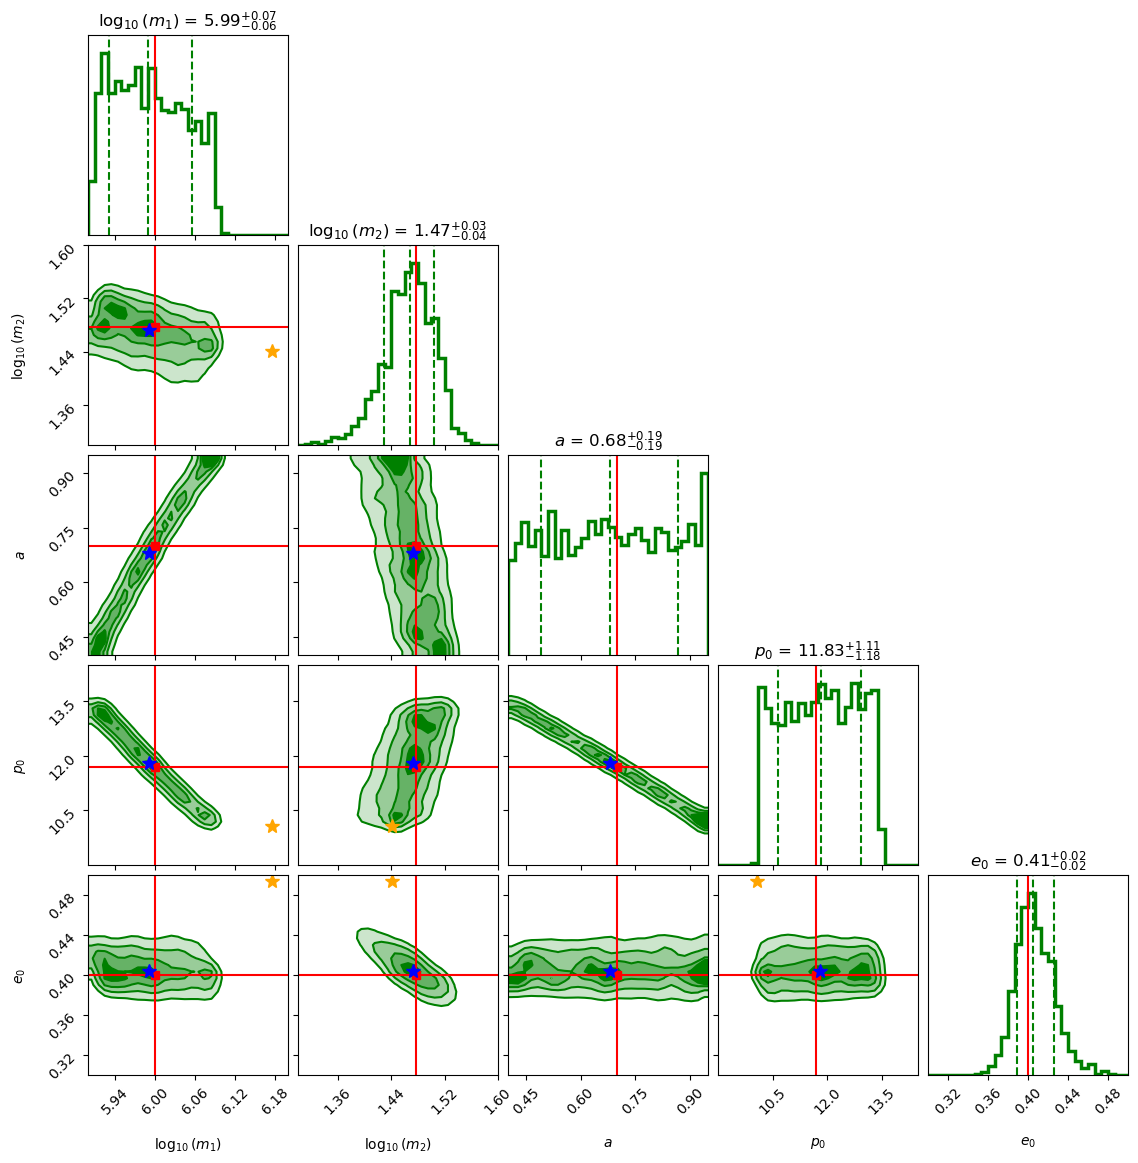

In [10]:
import corner
labels = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$']
fig = corner.corner(
    samples,
    weights=weights,
    labels=labels,
    truths=param_true,
    truth_color='red',
    color='green',
    show_titles=True,
    label_kwargs={"fontsize": 10},
    title_kwargs={"fontsize": 12},
    quantiles=[0.16, 0.5, 0.84],
    smooth=True,
    bins=30,
    plot_datapoints=False,
    hist_kwargs={"density": True, 'linewidth': 2.5},
    linewidth=2.5,
    fill_contours=True,
    range = param_ranges
)

corner.overplot_points(fig, maxld_pt_1.reshape(1, -1), 
                       color='blue', marker='*', ms=10, 
                       reverse=False)

corner.overplot_points(fig, maxld_pt_2.reshape(1, -1), 
                       color='orange', marker='*', ms=10,
                       reverse=False)



p0=8.00  loglike=0.003


p0=8.60  loglike=0.002
p0=9.20  loglike=0.009
p0=9.80  loglike=0.005
p0=10.40  loglike=0.038
p0=11.00  loglike=0.002
p0=11.70  loglike=5.948
p0=12.00  loglike=0.004
p0=12.80  loglike=0.105
p0=13.60  loglike=0.056
p0=14.40  loglike=0.026
p0=15.20  loglike=0.140
p0=16.00  loglike=0.291


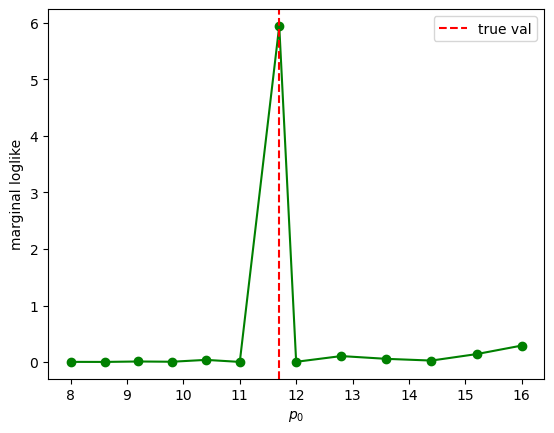

In [40]:
p0_grid = np.concatenate([
    np.linspace(8.0, 11.0, 6),  
    np.array([11.7]),            
    np.linspace(12.0, 16.0, 6),  
])

loglikes = []
for p0_test in p0_grid:
    ll = loglike_obj(np.array([m1, m2, a, p0_test, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]))
    loglikes.append(ll)
    print(f"p0={p0_test:.2f}  loglike={ll:.3f}")

loglikes = np.array(loglikes)

plt.figure()
plt.plot(p0_grid, loglikes, 'o-', color='green')
plt.axvline(11.7, color='red', linestyle='--', label='true val')
plt.xlabel('$p_0$')
plt.ylabel('marginal loglike')
plt.legend()
plt.show()